This notebook sets up the necessary libraries and environment for a MIMO detection. At present, we use CDL channel with 16qam modulation

Projected Gradient Descent (PGD) algorithm is implemented with three methods ("none", "16qam", "bbox").

Optuna to optimize hyperparameters (delta_k aka learning_rate and damping_factor) to minimize Symbol Error Rate (SER). The LMMSE equalizer is used as a tentative baseline for comparison.

# Libraries

In [2]:
# %pip install --upgrade kaleido
# %pip install -U sionna tensorflow plotly optuna -q
# %pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import sys
import tensorflow as tf

import numpy as np  ## Computations
from sionna.phy import Block  ## Base class for physical layer components
from sionna.phy.utils import compute_ser  ## Utility to compute Symbol Error Rate (SER)
# from sionna.phy.channel import FlatFadingChannel,  KroneckerModel  ## Rayleigh Flat-Fading Channel Model
from sionna.phy.channel.utils import exp_corr_mat  ## Exponential correlation matrics (based on antenna distance)
from sionna.phy.mimo import lmmse_equalizer  ## LLMSE Equaliser (Could be a baseline for Projective Gradient Descent Method Comparison)
from sionna.phy.mapping import SymbolDemapper, Mapper, QAMSource  ## QAM Symbol Mapping and Demapping Utilities

## Visualisation
%matplotlib inline
import matplotlib.pyplot as plt  ## For Static Plotting
import plotly.graph_objects as go  ## For Interactive Plotting
from plotly.subplots import make_subplots  ## Create Subplots in a single figure

from tqdm import tqdm  ## To track runtime progress

: 

## Importing CDL channel specific libraries

In [ ]:
from sionna.phy.mimo import StreamManagement  ## To handle multiple parallel data streams

from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, OFDMModulator, OFDMDemodulator, RZFPrecoder, RemoveNulledSubcarriers
# - ResourceGrid: defines the OFDM time–frequency grid (slots, subcarriers, pilots, etc.)
# - ResourceGridMapper: maps encoded symbols onto the grid (data + pilot placement)
# - LSChannelEstimator: least-squares channel estimation from pilot symbols
# - OFDMModulator: converts mapped symbols to time-domain OFDM waveforms (IFFT + CP)
# - OFDMDemodulator: inverse of above (removes CP + FFT back to frequency domain)
# - RZFPrecoder: regularized zero-forcing precoder for downlink multi-user MIMO
# - RemoveNulledSubcarriers: removes unused subcarriers (e.g., guard bands, DC)

from sionna.phy.channel.tr38901 import AntennaArray, CDL
from sionna.phy.channel import subcarrier_frequencies, cir_to_ofdm_channel, cir_to_time_channel, time_lag_discrete_time_channel, ApplyOFDMChannel, ApplyTimeChannel, OFDMChannel, TimeChannel
# - subcarrier_frequencies: computes OFDM subcarrier frequencies
# - cir_to_ofdm_channel: converts channel impulse response (CIR) → OFDM domain channel
# - cir_to_time_channel: converts CIR → time-domain discrete channel taps
# - time_lag_discrete_time_channel: generates time-lagged discrete channel representation
# - ApplyOFDMChannel: applies channel directly in frequency domain
# - ApplyTimeChannel: applies channel in time domain
# - OFDMChannel: convenience wrapper for OFDM channel simulation
# - TimeChannel: convenience wrapper for time-domain channel simulation

from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder  # If not already present
from sionna.phy.utils import ebnodb2no, sim_ber, compute_ber

In [8]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Dataset for MIMO

## User input

In [ ]:
# Fixed parameters based on requirements
num_tx_ant = 4  # Example transmitter antennas; adjust as needed
num_rx_ant = 8  # 2x transmitter (or set to 16 for 4x)
batch_size = 10000  # 500 channel realisations

num_bits_per_symbol = 4  # Keep for 16-QAM

carrier_frequency = 2.6e9  # Hz, as in tutorial
delay_spread = 300e-9  # Seconds, as in tutorial; adjust if needed
direction = "uplink"  # Or "downlink"
cdl_model = "B"  # Example from tutorial; choose A-E based on needs
speed = 10  # m/s, from tutorial

no = 0.25 ## scaling awgn during transmission

W0000 00:00:1757072358.413095  913068 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


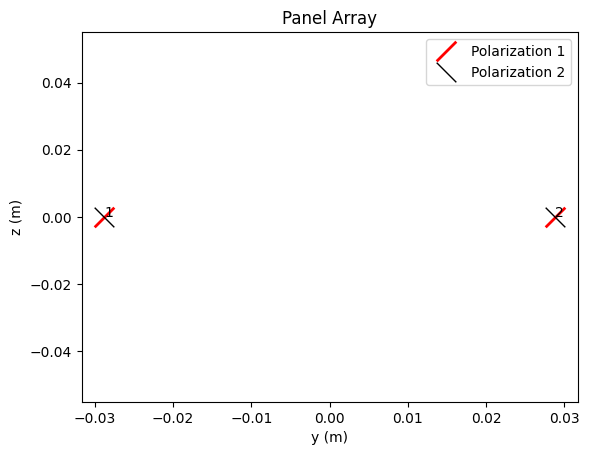

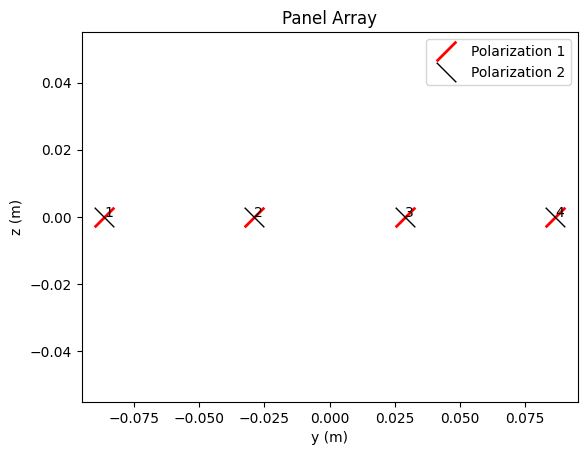

In [10]:
ut_array = AntennaArray(num_rows=1,
                        num_cols=int(num_tx_ant / 2),  # For dual polarization (cross, 2 parts)
                        polarization="dual",
                        polarization_type="cross",  # Cross-polarization (1,2, or 4 parts via num_cols)
                        antenna_pattern="38.901",  # Default
                        carrier_frequency=carrier_frequency)
bs_array = AntennaArray(num_rows=1,
                        num_cols=int(num_rx_ant / 2),
                        polarization="dual",
                        polarization_type="cross",
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)


ut_array.show()
bs_array.show()

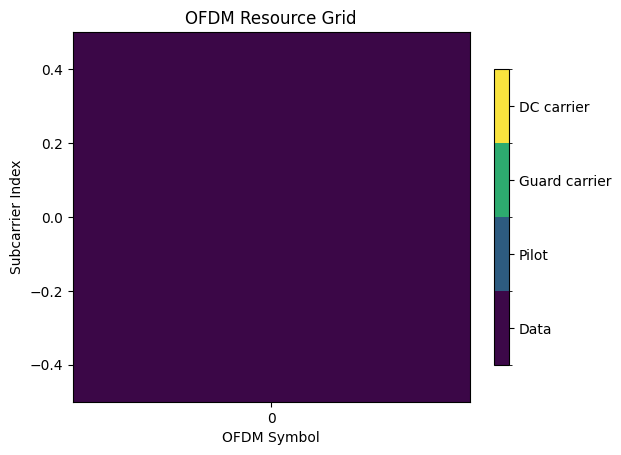

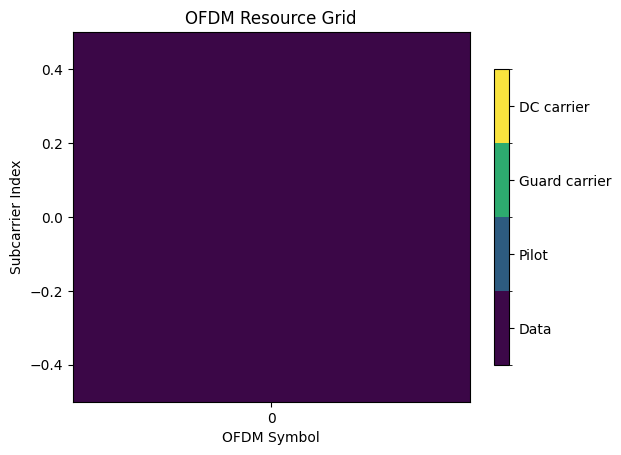

In [11]:
rg = ResourceGrid(  # Correct: Defines OFDM grid; minimal here for simplicity.
    num_ofdm_symbols=1,           # Number of OFDM symbols in the time domain (1 here)  # Single symbol: No time-varying.
    fft_size=1,                  # FFT size → number of subcarriers in frequency domain  # =1: Key simplification; flat-fading approx (no selectivity).
    subcarrier_spacing=15e3,       # Subcarrier spacing in Hz (15 kHz typical for LTE/5G)  # Standard; with fft_size=1, bandwidth=15kHz (narrowband).
    num_tx=1,                      # Number of transmit antennas (or antenna ports) used in grid  # =1: Treats UE as single "tx" with streams.
    num_streams_per_tx=num_tx_ant # Number of spatial streams per transmit antenna  # =4: MIMO layers = ants (full rank assumption).
)
rg.show()  # Good debug: Plots grid (pilots, guards—minimal here).

In [7]:
cdl = CDL(cdl_model, delay_spread, carrier_frequency, ut_array, bs_array, direction, min_speed=speed)  # Instantiates CDL with params; loads 3GPP tables for "B".

a, tau = cdl(batch_size=batch_size, num_time_steps=1, sampling_frequency=1/rg.ofdm_symbol_duration)  # Generates CIR; a (gains), tau (delays). sampling_freq from rg (high for small symbol duration)
frequencies = subcarrier_frequencies(rg.fft_size, rg.subcarrier_spacing)  # [0] Hz since fft_size=1
h_freq = cir_to_ofdm_channel(frequencies, a, tau, normalize=True)  # Transforms to freq-domain; normalize for unit power. h ~ [500,1,8,1,4,1,1].

# Reshape h to desired dimension: [batch_size, 1 (num_ues), num_tx_ant, 1 (num_rx_base), num_rx_ant, 1 (time), 500 (freq)]
#h = tf.transpose(h_freq, [0, 3, 4, 1, 2, 5, 6])  # Adjust indices: original [bs, rx=1, rx_ant, tx=1, tx_ant, time=1, freq=500]

h =h_freq
print("Shape of h:", h.shape)  # Verify

Shape of h: (500, 1, 8, 1, 4, 1, 1)


In [8]:
# Generate QAM symbols
qam_source = QAMSource(num_bits_per_symbol)
x_symbols = qam_source([batch_size, num_tx_ant])  # shape: [batch, tx_ant] aka 500,4


In [9]:
# For fft_size=1, no need for complex tiling; reshape for ResourceGridMapper
# ResourceGrid expects [batch, num_tx=1, num_streams_per_tx=4, num_ofdm_symbols=1, fft_size=1]
x_mapped = tf.reshape(x_symbols, [batch_size, 1, num_tx_ant, 1, 1])  # [500, 1, 4, 1, 1]
print("Shape of x_mapped:", x_mapped.shape)
print("Sum of x_mapped:", tf.reduce_sum(tf.abs(x_mapped)).numpy())

Shape of x_mapped: (500, 1, 4, 1, 1)
Sum of x_mapped: 1878.0969


In [10]:
# Simulate y using CDL channel
channel = ApplyOFDMChannel(add_awgn=True)
y = channel(x_mapped, h, no)  # [500, 1, 8, 1, 1]
print("Shape of y:", y.shape)
print("Sum of y:", tf.reduce_sum(tf.abs(y)).numpy())

Shape of y: (500, 1, 8, 1, 1)
Sum of y: 7260.8574


In [11]:
# Squeeze for PGD compatibility (assuming flat-fading PGD)
h_squeezed = tf.squeeze(h, axis=[1, 3, 5, 6])  # [500, 8, 4]
y_squeezed = tf.squeeze(y, axis=[1, 3, 4])  # [500, 8]
x_squeezed = tf.squeeze(x_mapped, axis=[1, 3, 4])  # [500, 4]
print("Squeezed shapes for PGD: h", h_squeezed.shape, "y", y_squeezed.shape, "x", x_squeezed.shape)

Squeezed shapes for PGD: h (500, 8, 4) y (500, 8) x (500, 4)


# Repeat Experiment Data

**Control Data**  Remember to run only the first cell of Dataset for Mimo

In [12]:
np.savez('mimo_pgd_results/control_data_cdl_model.npz', x=x_squeezed.numpy(), y=y_squeezed.numpy(), h=h_squeezed.numpy())

In [12]:
data = np.load('mimo_pgd_results/control_data_cdl_model.npz')
x = tf.convert_to_tensor(data['x'], dtype=tf.complex64)
y = tf.convert_to_tensor(data['y'], dtype=tf.complex64)
h = tf.convert_to_tensor(data['h'], dtype=tf.complex64)

**Initialising x_hat**

In [13]:
# Generating a single batch of random initial points outside the function
# initial_x_hat = tf.complex(
#         tf.random.uniform((num_tx_ant, 1), minval=-1.5, maxval=1.5, dtype=tf.float32),
#         tf.random.uniform((num_tx_ant, 1), minval=-1.5, maxval=1.5, dtype=tf.float32)
#     )

# print(initial_x_hat)

# 1) Random and fixed (generated once and saved)
initial_x_hat_random = tf.constant(
    tf.complex(
        [[-0.8861958, 0.97434497, 0.95024633, 0.23440576]],
        [[-1.1165918, 1.0869036, -0.2531011, -1.1991398]]
    ),
    dtype=tf.complex64,
    shape=(num_tx_ant, 1))

# 2) All zeros
initial_x_hat_zeros = tf.zeros((num_tx_ant, 1), dtype=tf.complex64)

print("Fixed Random Initial x_hat:\n", initial_x_hat_random.numpy())
print("Zeros Initial x_hat:\n", initial_x_hat_zeros.numpy())


Fixed Random Initial x_hat:
 [[-0.8861958 -1.1165918j]
 [ 0.97434497+1.0869036j]
 [ 0.95024633-0.2531011j]
 [ 0.23440576-1.1991398j]]
Zeros Initial x_hat:
 [[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]


In [14]:
# h_squeezed[:3]

initial_x_hat = initial_x_hat_random  # Choose initial point for PGD
# initial_x_hat = initial_x_hat_zeros  # Or use zeros

## LMMSE as baseline

**LMMSE Equalizer Baseline**:
   - Implements the Linear Minimum Mean Square Error (LMMSE) equalizer to estimate transmitted symbols.
   - Computes SER and effective noise variance for benchmarking PGD performance.
   - Visualizes transmitted and received constellations.

Effective Noise Variance (LMMSE): 0.12390786
Theoretical Estimated Noise Variance (LMMSE): 0.12542857
Symbol Error Rate (LMMSE): 0.246


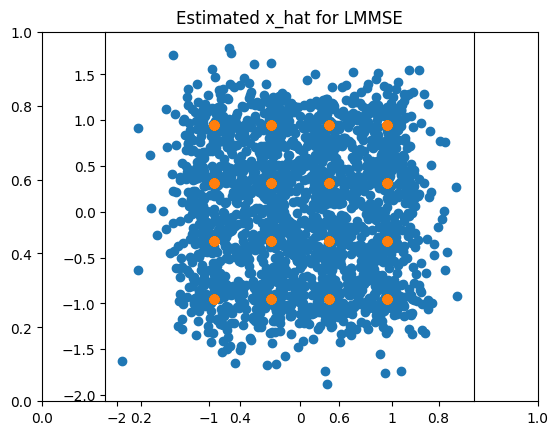

In [15]:
symbol_demapper = SymbolDemapper("qam", num_bits_per_symbol, hard_out=True)  # QAM symbol demapper (hard decision) to map received signals back to symbol indices
x_ind = symbol_demapper(x, no)  # Get true transmitted symbol indices from original QAM symbols
s = tf.cast(no * tf.eye(num_rx_ant, num_rx_ant), y.dtype)  # Regularization matrix for LMMSE: s = σ_n² * I (noise variance times identity)

x_hat_lmmse, no_eff = lmmse_equalizer(y, h, s)   # Apply LMMSE equalizer to estimate transmitted symbols and get effective noise variance
x_ind_lmmse = symbol_demapper(x_hat_lmmse, no)  # Demap LMMSE-estimated symbols to indices

ser_lmmse = compute_ser(x_ind, x_ind_lmmse)  # Compute Symbol Error Rate (SER) between true and LMMSE-estimated symbols

noise_var_eff = np.var(x - x_hat_lmmse)  # Compute effective noise variance from LMMSE estimates
noise_var_est = np.mean(no_eff)           # Theoretical estimated noise variance

print("Effective Noise Variance (LMMSE):", noise_var_eff)  ## Just confirming the correctness of the LMMSE estimate
print("Theoretical Estimated Noise Variance (LMMSE):", noise_var_est)
print("Symbol Error Rate (LMMSE):", ser_lmmse.numpy())  # SER achieved by LMMSE baseline


## Plotting Transmitted and Received Constellation
plt.title("Estimated x_hat for LMMSE")
plt.axes().set_aspect(1.0)
plt.scatter(np.real(x_hat_lmmse), np.imag(x_hat_lmmse));
plt.scatter(np.real(x), np.imag(x));

## Mapper function and constellation

**Define and verify 16-QAM constellation points**

In [16]:
mapper = Mapper("qam", num_bits_per_symbol) ## Initialize a Mapper for 16-QAM with specified bits per symbol
constellation = mapper.constellation.points.numpy()  ## Extract the constellation points as a NumPy array
print("16-QAM Constellation Points:", constellation)

16-QAM Constellation Points: [ 0.31622776+0.31622776j  0.31622776+0.94868326j  0.94868326+0.31622776j
  0.94868326+0.94868326j  0.31622776-0.31622776j  0.31622776-0.94868326j
  0.94868326-0.31622776j  0.94868326-0.94868326j -0.31622776+0.31622776j
 -0.31622776+0.94868326j -0.94868326+0.31622776j -0.94868326+0.94868326j
 -0.31622776-0.31622776j -0.31622776-0.94868326j -0.94868326-0.31622776j
 -0.94868326-0.94868326j]


The below function would be used to compute Mean Squared Error (MSE) of received signal y with respect to hard-decision x_hat

In [17]:
## Could not find the utility in Sionna that maps indices of QAM constellation to the corresponding complex numbers. Hence done manally. Verified the correctness
constellation_dict = {i: constellation[i] for i in range(16)}  # Create a dictionary mapping indices to complex values

@tf.function
def map_indices_to_complex(indices):
    """Maps integer indices to complex constellation points using tf.gather."""
    indices = tf.clip_by_value(indices, 0, 15) # Ensure indices are within valid range [0, 15]
    constellation_tensor = tf.convert_to_tensor(list(constellation_dict.values()), dtype=tf.complex64) # Convert constellation dictionary to a tensor
    mapped_values = tf.gather(constellation_tensor, indices) # Use tf.gather to map indices to constellation points
    return tf.reshape(mapped_values, tf.shape(indices)) # Reshape to maintain original shape

## Just checking the output of indices and corresponding constellation
# print(x_ind_lmmse)

# dummy_sample = map_indices_to_complex(x_ind_lmmse)
# print("\n\n",dummy_sample)

To ensure gradient descent convergence, delta_k should ideally follow **2 / max(eigenvalue(H^H H))**

Computing this per sample is costly, so we can use the smallest value overall.

Even if delta_k is suboptimal, Optuna will help tune it for least SER.  (Since we are not using Optuna now, Let us run the exhaustive list of delta_k)

## Visualisation to determine the threshold for learning rate

In [18]:
def compute_and_plot_delta_k_thresholds(h, batch_size):
    """
    Compute delta_k thresholds (2 / max eigenvalue of H^H H) for each channel sample to ensure
    gradient descent convergence. Plot a histogram and scatter plot of thresholds, and print
    statistical measures including the minimum threshold across the batch.

    Args:
        h (tf.Tensor): Channel matrices, shape [batch_size, num_rx_ant, num_tx_ant].
        batch_size (int): Number of samples in the batch.

    Returns:
        tuple: (delta_k_median, delta_values, delta_k_min)
            - delta_k_median (float): Median delta_k threshold across samples.
            - delta_values (list): Suggested delta_k values for PGD experiments.
            - delta_k_min (float): Minimum delta_k threshold across samples.
    """
    # Initialize list to store delta_k thresholds for each sample
    delta_k_thresholds = []

    # Compute delta_k threshold for each sample based on maximum eigenvalue of H^H H
    for batch_idx in range(batch_size):
        # Extract channel matrix H for current sample, shape: (num_rx_ant, num_tx_ant)
        H = h[batch_idx, :, :]
        # Compute H^H H (Hermitian transpose of H times H), shape: (num_tx_ant, num_tx_ant)
        HTH = tf.matmul(tf.transpose(H, conjugate=True), H)
        # Calculate real eigenvalues of H^H H
        eigenvalues = tf.math.real(tf.linalg.eigvalsh(HTH))
        # Get maximum eigenvalue
        lambda_max = tf.reduce_max(eigenvalues)
        # Compute delta_k threshold as 2 / max eigenvalue for convergence
        delta_k_thresholds.append(2.0 / lambda_max)

    # Convert thresholds to a tensor for processing
    delta_k_thresholds = tf.stack(delta_k_thresholds)  # Shape: [batch_size]

    # Compute statistical measures for delta_k thresholds
    delta_k_median = np.median(delta_k_thresholds.numpy())
    delta_k_min = tf.reduce_min(delta_k_thresholds).numpy()

    # Suggest delta_k values for Projected Gradient Descent (PGD) experiments
    delta_values = [delta_k_median * k for k in [0.5, 1.0, 1.25]]

    # Print median, minimum, and suggested delta_k values
    print(f"Median delta_k threshold: {delta_k_median:.6f}")
    print(f"Minimum delta_k threshold: {delta_k_min:.6f}")
    print(f"Suggested delta_k values based on the median delta_k threshold multiplied by [0.5, 1.0, 1.25].: {[f'{d:.6f}' for d in delta_values]}")

    # Create a 2-frame subplot for visualizing delta_k thresholds
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            "Histogram of delta_k Thresholds",
            "Scatter Plot of delta_k Thresholds"
        ),
        horizontal_spacing=0.1
    )

    # Frame 1: Histogram of delta_k thresholds
    fig.add_trace(
        go.Histogram(
            x=delta_k_thresholds.numpy(),
            nbinsx=30,  # Number of bins for clear visualization
            name="delta_k Thresholds",
            marker_color="skyblue",  # Light color for better visibility
            opacity=0.8,  # Slightly transparent for clarity
            histnorm="probability density",  # Normalize to probability density
            showlegend=False
        ),
        row=1, col=1
    )
    # Add vertical line for median in histogram
    fig.add_vline(
        x=delta_k_median,
        line=dict(color="red", width=2, dash="dash"),
        annotation_text=f"Median: {delta_k_median:.3f}",
        annotation_position="top right",
        annotation=dict(font_size=12),
        row=1, col=1
    )
    # Add vertical line for minimum in histogram
    fig.add_vline(
        x=delta_k_min,
        line=dict(color="blue", width=2, dash="solid"),
        annotation_text=f"Min: {delta_k_min:.3f}",
        annotation_position="top left",
        annotation=dict(font_size=12),
        row=1, col=1
    )
    # Add vertical lines for suggested delta_k values
    for delta in delta_values:
        fig.add_vline(
            x=delta,
            line=dict(color="green", width=1, dash="dot"),
            annotation_text=f"{delta:.3f}",
            annotation_position="top left",
            annotation=dict(font_size=10),
            row=1, col=1
        )

    # Frame 2: Scatter plot of delta_k thresholds
    fig.add_trace(
        go.Scatter(
            x=list(range(batch_size)),
            y=delta_k_thresholds.numpy(),
            mode="markers",
            name="delta_k Thresholds",
            marker=dict(
                color="blue",
                size=6,  # Smaller markers to reduce clutter
                opacity=0.6  # Semi-transparent to avoid overlap
            ),
            showlegend=False
        ),
        row=1, col=2
    )
    # Add horizontal line for median in scatter plot
    fig.add_hline(
        y=delta_k_median,
        line=dict(color="red", width=2, dash="dash"),
        annotation_text=f"Median: {delta_k_median:.3f}",
        annotation_position="top right",
        annotation=dict(font_size=12),
        row=1, col=2
    )
    # Add horizontal line for minimum in scatter plot
    fig.add_hline(
        y=delta_k_min,
        line=dict(color="blue", width=2, dash="solid"),
        annotation_text=f"Min: {delta_k_min:.3f}",
        annotation_position="top left",
        annotation=dict(font_size=12),
        row=1, col=2
    )
    # Add horizontal lines for suggested delta_k values
    for delta in delta_values:
        fig.add_hline(
            y=delta,
            line=dict(color="green", width=1, dash="dot"),
            annotation_text=f"{delta:.3f}",
            annotation_position="right",
            annotation=dict(font_size=10),
            row=1, col=2
        )

    # Update plot layout for clarity and aesthetics
    fig.update_layout(
        title=dict(
            text="Distribution of delta_k Thresholds (2 / max eigenvalue of H^H H) Across Samples",
            font=dict(size=14),
            x=0.5,
            xanchor="center"
        ),
        width=1400,  # Wide layout for better visibility
        height=500,  # Moderate height
        plot_bgcolor="rgba(255, 255, 255, 0.1)",  # Light background
        paper_bgcolor="rgba(255, 255, 255, 0.1)",
        font=dict(color="white", size=12),  # Clear, readable font
        showlegend=False,
        margin=dict(l=50, r=50, t=80, b=50)  # Adjusted margins
    )

    # Update axes for histogram
    fig.update_xaxes(
        title_text="delta_k Threshold",
        gridcolor="rgba(255, 255, 255, 0.3)",
        color="white",
        row=1, col=1
    )
    fig.update_yaxes(
        title_text="Probability Density",
        gridcolor="rgba(255, 255, 255, 0.3)",
        color="white",
        row=1, col=1
    )

    # Update axes for scatter plot
    fig.update_xaxes(
        title_text="Sample Index",
        gridcolor="rgba(255, 255, 255, 0.3)",
        color="white",
        row=1, col=2
    )
    fig.update_yaxes(
        title_text="delta_k Threshold",
        gridcolor="rgba(255, 255, 255, 0.3)",
        color="white",
        row=1, col=2
    )

    # Display the plot
    fig.show()

    return delta_k_median, delta_values, delta_k_min

In [20]:
delta_k_median, delta_values, delta_k_min = compute_and_plot_delta_k_thresholds(h, batch_size)

Median delta_k threshold: 0.100410
Minimum delta_k threshold: 0.073475
Suggested delta_k values based on the median delta_k threshold multiplied by [0.5, 1.0, 1.25].: ['0.050205', '0.100410', '0.125512']


# PGD

**The delta_k_threshold is 0.0745 for the repeat experiment**

## Projection Functions

In [19]:
@tf.function  # Ensures this function is compiled into a TensorFlow graph ## Remember we pass 1 batch at a time
def project_to_16qam_tf(x_hat, constellation, damping_factor=0.05):
    x_hat_complex = tf.complex(tf.math.real(x_hat), tf.math.imag(x_hat)) ## dummy assign
    const_expanded = tf.cast(constellation, x_hat.dtype)  ## Ensure the data type of constellation and x_hat is same   [16,]
    distances = tf.abs(x_hat_complex[:, tf.newaxis] - const_expanded) ## For each sample and antenna, this tensor contains the differences between the symbol and each of the 16 constellation points.  ## [tx,] to [tx, 16]
    min_indices = tf.argmin(distances, axis=-1)  ## Compute the index of minimum value of each row [tx,]
    nearest_points = tf.gather(const_expanded, min_indices)  ## [tx,]
    adjustment = damping_factor * (nearest_points - x_hat_complex)  ## Move towards the difference
    return x_hat_complex + adjustment


@tf.function
def project_to_bbox_tf(x_hat, damping_factor = 1.0 , min_val=-0.95, max_val=0.95):
    """Projects complex tensor onto a bounding box by clipping real and imaginary parts."""
    real_part = tf.clip_by_value(tf.math.real(x_hat), min_val, max_val)
    imag_part = tf.clip_by_value(tf.math.imag(x_hat), min_val, max_val)

    x_projected = tf.complex(real_part, imag_part)
    adjustment = damping_factor * (x_projected - x_hat)

    return x_hat + adjustment  ## If damping = 1.0, (Pure bbox) ,then x_hat + x_projected - x_hat = x_projected

## Core Algorithm

In [20]:
## Remember we pass 1 batch at a time
@tf.function
def projected_gradient_descent_one_step(y, H, delta_k, x_hat_k, type="none", constellation=None, damping_factor=0.05, eps=1e-8, complex_eigen_calculation=False):
    """
    Arguments
        y: [num_rx_ant, 1].
        H: [num_rx_ant, num_tx_ant].
        delta_k: Step size for gradient update.
        x_hat_k: Current estimate of transmitted symbols [ num_tx_ant, 1].
        type: Projection type ("none", "16qam", "bbox").
        constellation: 16-QAM constellation points (required for "16qam").
        damping_factor: Damping factor for projection.
        eps: Small constant to avoid division by zero.
        complex_eigen_calculation: If True, clip delta_k using eigenvalue-based threshold.

    Returns:
        x_hat_k: Updated estimate after one PGD step
        x_hat_k_unprojected: Unprojected estimate before projection.
    """
    # CastING inputs to complex64 for consistent computations
    H = tf.cast(H, tf.complex64)
    y = tf.cast(y, tf.complex64)
    x_hat_k = tf.cast(x_hat_k, tf.complex64)
    damping_factor_tf = tf.cast(damping_factor, dtype=tf.complex64)

    # Compute Hermitian adjoint and related terms
    H_adj = tf.linalg.adjoint(H)  # H^H
    H_adj_y = H_adj @ y  # H^H y
    H_HH = H_adj @ H  # H^H H for Hessian term

    # Determine delta_k based on complex_eigen_calculation  (I think it should be maximum if we give preference to faster convergence)
    if complex_eigen_calculation:
        max_eig = tf.reduce_max(tf.math.real(tf.linalg.eigvalsh(H_HH)))
        delta_k_clipped = tf.minimum(tf.cast(delta_k, tf.float32), 2.0 / (max_eig + eps))
    else:
        delta_k_clipped = tf.cast(delta_k, tf.float32) ## Choosing the default threshold which you entered earlier

    # Compute gradient and update
    hessian_term_x = H_HH @ x_hat_k  # H^H H x_hat_k
    grad = hessian_term_x - H_adj_y  # Gradient of loss term
    update = -tf.cast(delta_k_clipped, tf.complex64) * grad  # Negation for loss minimization
    x_hat_k_unprojected = x_hat_k + update

    # Apply projection
    if type == "none":
        x_hat_k = x_hat_k_unprojected
    elif type == "16qam":
        if constellation is None:
            raise ValueError("Constellation required for 16qam")
        x_hat_k = project_to_16qam_tf(x_hat_k_unprojected, constellation, damping_factor_tf)
    elif type == "bbox":
        x_hat_k = project_to_bbox_tf(x_hat_k_unprojected, damping_factor_tf)

    return x_hat_k, x_hat_k_unprojected

## Function to implement the algorithm and store the trajectories

In [21]:
@tf.function
def store_trajectories_and_metrics(y, H, initial_x_hat, delta_k, num_iterations, type="none", constellation=None, damping_factor=0.05, eps=1e-8, complex_eigen_calculation=False, true_x=None, no=None, start_iter=0, existing_projected_trajectory=None, existing_unprojected_trajectory=None, existing_mse_y_trajectory=None, existing_mse_y_hard_trajectory=None, existing_mse_x_trajectory=None, existing_mse_unproj_x_trajectory=None, existing_ser_trajectory=None, existing_distortion_trajectory=None, existing_distortion_ant_trajectory=None):
    """
    Run Projected Gradient Descent (PGD) for one batch and store trajectories and metrics.
    Supports resuming from a specific iteration by concatenating new results with existing ones.

    Args:
        y: Received signal, shape [num_rx_ant, 1].
        H: Channel matrix, shape [num_rx_ant, num_tx_ant].
        initial_x_hat: Initial estimate, shape [num_tx_ant, 1].
        delta_k: Step size for gradient update.
        num_iterations: Total number of PGD iterations.
        type: Projection type ("none", "16qam", "bbox").
        constellation: 16-QAM constellation points (for "16qam").
        damping_factor: Damping factor for projection.
        eps: Small constant to avoid division by zero.
        complex_eigen_calculation: If True, clip delta_k using eigenvalue-based threshold.
        true_x: True transmitted symbols, shape [1, num_tx_ant].
        no: Noise variance for demapping.
        start_iter: Iteration to resume from (0 for fresh start).
        existing_*: Existing trajectories/metrics for resuming (None if starting fresh).

    Returns:
        Tuple of (x_hat_k, projected_trajectory, unprojected_trajectory, mse_y_trajectory,
                  mse_y_hard_trajectory, mse_x_trajectory, mse_unproj_x_trajectory,
                  ser_trajectory, distortion_trajectory, distortion_ant_trajectory).
    """
    # Restore x_hat_k from last projected point if resuming
    if start_iter > 0 and existing_projected_trajectory is not None:
        last_proj = existing_projected_trajectory[start_iter]  # Shape: [2*num_tx_ant]
        real_part = last_proj[:num_tx_ant]
        imag_part = last_proj[num_tx_ant:]
        x_hat_k = tf.complex(real_part, imag_part)[:, tf.newaxis]  # Shape: [num_tx_ant, 1]
    else:
        x_hat_k = tf.cast(initial_x_hat, tf.complex64)

    # Initialize TensorArrays for new data (only for remaining iterations)
    num_remaining = num_iterations - start_iter
    projected_trajectory_ta = tf.TensorArray(tf.float32, size=num_remaining)
    unprojected_trajectory_ta = tf.TensorArray(tf.float32, size=num_remaining)
    mse_y_trajectory_ta = tf.TensorArray(tf.float32, size=num_remaining)
    mse_y_hard_trajectory_ta = tf.TensorArray(tf.float32, size=num_remaining)
    mse_x_trajectory_ta = tf.TensorArray(tf.float32, size=num_remaining)
    mse_unproj_x_trajectory_ta = tf.TensorArray(tf.float32, size=num_remaining)
    ser_trajectory_ta = tf.TensorArray(tf.float32, size=num_remaining)
    distortion_ta = tf.TensorArray(tf.float32, size=num_remaining)
    distortion_ant_ta = tf.TensorArray(tf.float32, size=num_remaining, element_shape=(num_tx_ant,))

    # Cast true_x to complex64 if provided
    true_x = tf.cast(true_x, tf.complex64) if true_x is not None else None

    # Main PGD Loop (only for remaining iterations)
    for k in tf.range(start_iter, num_iterations):
        x_hat_k, x_hat_k_unprojected = projected_gradient_descent_one_step(
            y, H, delta_k, x_hat_k, type, constellation, damping_factor, eps, complex_eigen_calculation
        )

        # Index in the new TensorArray
        ta_idx = k - start_iter

        # Store trajectories (flatten complex to real/imag parts)
        projected_trajectory_ta = projected_trajectory_ta.write(ta_idx, tf.concat([tf.math.real(x_hat_k)[:, 0], tf.math.imag(x_hat_k)[:, 0]], axis=0))
        unprojected_trajectory_ta = unprojected_trajectory_ta.write(ta_idx, tf.concat([tf.math.real(x_hat_k_unprojected)[:, 0], tf.math.imag(x_hat_k_unprojected)[:, 0]], axis=0))

        # Calculate and store metrics
        distortion = tf.cast(tf.reduce_mean(tf.square(tf.abs(x_hat_k_unprojected - x_hat_k))), tf.float32)
        distortion_ta = distortion_ta.write(ta_idx, distortion)
        distortion_ant = tf.cast(tf.squeeze(tf.square(tf.abs(x_hat_k_unprojected - x_hat_k)), axis=-1), tf.float32)
        distortion_ant_ta = distortion_ant_ta.write(ta_idx, distortion_ant)

        Hx_hat = tf.matmul(H, x_hat_k)
        mse_y = tf.cast(tf.reduce_mean(tf.square(tf.abs(y - Hx_hat))), tf.float32)
        mse_y_trajectory_ta = mse_y_trajectory_ta.write(ta_idx, mse_y)

        # Compute hard-decision symbols with correct shape
        x_hat_indices = symbol_demapper(x_hat_k, no)  # Shape: [num_tx_ant, 1]
        x_hat_indices = tf.squeeze(x_hat_indices, axis=-1)  # Shape: [num_tx_ant]
        x_hat_hard = map_indices_to_complex(x_hat_indices)  # Shape: [num_tx_ant]
        x_hat_hard = tf.reshape(x_hat_hard, [num_tx_ant, 1])  # Shape: [num_tx_ant, 1]
        Hx_hat_hard = tf.matmul(H, x_hat_hard)  # Shape: [num_rx_ant, 1]
        mse_y_hard = tf.cast(tf.reduce_mean(tf.square(tf.abs(y - Hx_hat_hard))), tf.float32)
        mse_y_hard_trajectory_ta = mse_y_hard_trajectory_ta.write(ta_idx, mse_y_hard)

        if true_x is not None:
            mse_x = tf.cast(tf.reduce_mean(tf.square(tf.abs(true_x - tf.transpose(x_hat_k)))), tf.float32)
            mse_x_ant = tf.cast(tf.squeeze(tf.square(tf.abs(true_x - tf.transpose(x_hat_k))), axis=0), tf.float32)
            mse_unproj_x = tf.cast(tf.reduce_mean(tf.square(tf.abs(true_x - tf.transpose(x_hat_k_unprojected)))), tf.float32)
            mse_unproj_x_ant = tf.cast(tf.squeeze(tf.square(tf.abs(true_x - tf.transpose(x_hat_k_unprojected))), axis=0), tf.float32)

            x_ind_true = symbol_demapper(true_x, no)  # Shape: [num_tx_ant, 1]
            x_ind_hat = symbol_demapper(tf.transpose(x_hat_k), no)  # Shape: [num_tx_ant, 1]
            ser = tf.cast(compute_ser(x_ind_true, x_ind_hat), tf.float32)
        else:
            mse_x, mse_unproj_x, ser = 0.0, 0.0, 0.0
            mse_x_ant = tf.zeros(num_tx_ant, dtype=tf.float32)
            mse_unproj_x_ant = tf.zeros(num_tx_ant, dtype=tf.float32)

        mse_x_trajectory_ta = mse_x_trajectory_ta.write(ta_idx, mse_x)
        mse_unproj_x_trajectory_ta = mse_unproj_x_trajectory_ta.write(ta_idx, mse_unproj_x)
        ser_trajectory_ta = ser_trajectory_ta.write(ta_idx, ser)

    # Stack new data
    new_projected_trajectory = projected_trajectory_ta.stack()  # Shape: [num_remaining, 2*num_tx_ant]
    new_unprojected_trajectory = unprojected_trajectory_ta.stack()
    new_mse_y_trajectory = mse_y_trajectory_ta.stack()  # Shape: [num_remaining]
    new_mse_y_hard_trajectory = mse_y_hard_trajectory_ta.stack()
    new_mse_x_trajectory = mse_x_trajectory_ta.stack()
    new_mse_unproj_x_trajectory = mse_unproj_x_trajectory_ta.stack()
    new_ser_trajectory = ser_trajectory_ta.stack()
    new_distortion = distortion_ta.stack()
    new_distortion_ant = distortion_ant_ta.stack()  # Shape: [num_remaining, num_tx_ant]

    # Concatenate with existing data if resuming
    if start_iter > 0 and existing_projected_trajectory is not None:
        projected_trajectory = tf.concat([existing_projected_trajectory[:start_iter+1], new_projected_trajectory], axis=0)
        unprojected_trajectory = tf.concat([existing_unprojected_trajectory[:start_iter+1], new_unprojected_trajectory], axis=0)
        mse_y_trajectory = tf.concat([existing_mse_y_trajectory[:start_iter+1], new_mse_y_trajectory], axis=0)
        mse_y_hard_trajectory = tf.concat([existing_mse_y_hard_trajectory[:start_iter+1], new_mse_y_hard_trajectory], axis=0)
        mse_x_trajectory = tf.concat([existing_mse_x_trajectory[:start_iter+1], new_mse_x_trajectory], axis=0)
        mse_unproj_x_trajectory = tf.concat([existing_mse_unproj_x_trajectory[:start_iter+1], new_mse_unproj_x_trajectory], axis=0)
        ser_trajectory = tf.concat([existing_ser_trajectory[:start_iter+1], new_ser_trajectory], axis=0)
        distortion_trajectory = tf.concat([existing_distortion_trajectory[:start_iter+1], new_distortion], axis=0)
        distortion_ant_trajectory = tf.concat([existing_distortion_ant_trajectory[:start_iter+1], new_distortion_ant], axis=0)
    else:
        projected_trajectory = new_projected_trajectory
        unprojected_trajectory = new_unprojected_trajectory
        mse_y_trajectory = new_mse_y_trajectory
        mse_y_hard_trajectory = new_mse_y_hard_trajectory
        mse_x_trajectory = new_mse_x_trajectory
        mse_unproj_x_trajectory = new_mse_unproj_x_trajectory
        ser_trajectory = new_ser_trajectory
        distortion_trajectory = new_distortion
        distortion_ant_trajectory = new_distortion_ant

    return (
        x_hat_k,  # Shape: [num_tx_ant, 1]
        projected_trajectory,  # Shape: [num_iterations, 2*num_tx_ant]
        unprojected_trajectory,
        mse_y_trajectory,  # Shape: [num_iterations]
        mse_y_hard_trajectory,
        mse_x_trajectory,
        mse_unproj_x_trajectory,
        ser_trajectory,
        distortion_trajectory,
        distortion_ant_trajectory  # Shape: [num_iterations, num_tx_ant]
    )

# Manual PGD Run

## Functions to collect the parameters and run pgd

In [22]:
import pickle

# Set results directory
results_dir = os.path.join(os.getcwd(), "mimo_pgd_results")
os.makedirs(results_dir, exist_ok=True)

# Save checkpoint for method
def save_checkpoint(method, results, iteration, batch_idx):
    checkpoint_path = os.path.join(results_dir, f"checkpoint_{method}_batch_{batch_idx}.pkl")
    with open(checkpoint_path, 'wb') as f:
        pickle.dump({'results': results[method], 'iteration': iteration}, f)
    print(f"Checkpoint saved: {checkpoint_path}")

# Load checkpoint for method
def load_checkpoint(method, batch_idx):
    checkpoint_path = os.path.join(results_dir, f"checkpoint_{method}_batch_{batch_idx}.pkl")
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'rb') as f:
            checkpoint = pickle.load(f)
        return checkpoint['results'], checkpoint['iteration']
    return None, 0


In [23]:
# delta_values = np.arange(0.005, 0.161, 0.002).tolist()  # ~78 values

# Initialize parameters and results
def collect_pgd_parameters(num_iterations=800):
    results = {"none": {}, "16qam": {}, "bbox": {}}
    delta_values = [0.005, 0.0738, 0.015]
    delta_values_none = delta_values
    delta_values_16qam = delta_values
    delta_values_bbox = delta_values
    damping_values = [0.005,0.5,0.75,1.0]
    damping_values_16qam = []
    damping_values_bbox = []

    # Initialize none results
    for delta in delta_values_none:
        key = f"delta_{delta:.4f}"
        results["none"][key] = {
            "x_hat": [], "projected_trajectory": [], "unprojected_trajectory": [],
            "mse_y": [], "mse_y_hard": [], "mse_x": [], "mse_unproj_x": [], "ser": [], "distortion": [],
            "distortion_ant": []
        }

    # Initialize 16qam results
    for delta in delta_values_16qam:
        for damping in damping_values:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            results["16qam"][key] = {
                "x_hat": [], "projected_trajectory": [], "unprojected_trajectory": [],
                "mse_y": [], "mse_y_hard": [], "mse_x": [], "mse_unproj_x": [], "ser": [], "distortion": [],
                "distortion_ant": []
            }
            damping_values_16qam.append(damping)

    # Initialize bbox results
    for delta in delta_values_bbox:
        for damping in damping_values:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            results["bbox"][key] = {
                "x_hat": [], "projected_trajectory": [], "unprojected_trajectory": [],
                "mse_y": [], "mse_y_hard": [], "mse_x": [], "mse_unproj_x": [], "ser": [], "distortion": [],
                "distortion_ant": []
            }
            damping_values_bbox.append(damping)

    return results, delta_values_none, delta_values_16qam, damping_values_16qam, delta_values_bbox, damping_values_bbox, num_iterations


In [24]:
def run_pgd_experiments(y, h, x, initial_x_hat, constellation, no_demap, batch_size, num_tx_ant, x_ind, x_hat_lmmse=None, symbol_demapper=None, compute_ser=None, ser_lmmse=None):
    results, delta_values_none, delta_values_16qam, damping_values_16qam, delta_values_bbox, damping_values_bbox, num_iterations = collect_pgd_parameters()
    checkpoint_freq = 500  # Save after every batch for better resuming
    ser_list = []

    with tqdm(total=batch_size, desc="Batch", unit="batch") as pbar:
        for batch_idx in range(batch_size):
            y_sample = tf.transpose(y[batch_idx:batch_idx+1, :])
            h_sample = h[batch_idx, :, :]
            x_sample = x[batch_idx:batch_idx+1, :]

            # Load checkpoint
            checkpoint_batch = batch_idx - (batch_idx % checkpoint_freq) if batch_idx >= checkpoint_freq else 0
            none_results, _ = load_checkpoint("none", checkpoint_batch)
            qam_results, _ = load_checkpoint("16qam", checkpoint_batch)
            bbox_results, _ = load_checkpoint("bbox", checkpoint_batch)
            if none_results: results["none"] = none_results
            if qam_results: results["16qam"] = qam_results
            if bbox_results: results["bbox"] = bbox_results

            # === NONE ===
            for delta in delta_values_none:
                key = f"delta_{delta:.4f}"
                existing_proj = results["none"][key]["projected_trajectory"][batch_idx] if batch_idx < len(results["none"][key]["x_hat"]) else None
                start_iter = existing_proj.shape[0]-1 if existing_proj is not None else 0
                if start_iter >= num_iterations: continue
                existing_unproj = results["none"][key]["unprojected_trajectory"][batch_idx] if existing_proj is not None else None
                existing_mse_y = results["none"][key]["mse_y"][batch_idx] if existing_proj is not None else None
                existing_mse_y_hard = results["none"][key]["mse_y_hard"][batch_idx] if existing_proj is not None else None
                existing_mse_x = results["none"][key]["mse_x"][batch_idx] if existing_proj is not None else None
                existing_mse_unproj_x = results["none"][key]["mse_unproj_x"][batch_idx] if existing_proj is not None else None
                existing_ser = results["none"][key]["ser"][batch_idx] if existing_proj is not None else None
                existing_distortion = results["none"][key]["distortion"][batch_idx] if existing_proj is not None else None
                existing_distortion_ant = results["none"][key]["distortion_ant"][batch_idx] if existing_proj is not None else None

                x_hat, proj_traj, unproj_traj, mse_y, mse_y_hard, mse_x, mse_unproj_x, ser, distortion, distortion_ant = store_trajectories_and_metrics(
                    y_sample, h_sample, initial_x_hat, delta, num_iterations, true_x=x_sample, no=no_demap, type="none", constellation=constellation,
                    start_iter=start_iter, existing_projected_trajectory=existing_proj, existing_unprojected_trajectory=existing_unproj,
                    existing_mse_y_trajectory=existing_mse_y, existing_mse_y_hard_trajectory=existing_mse_y_hard,
                    existing_mse_x_trajectory=existing_mse_x, existing_mse_unproj_x_trajectory=existing_mse_unproj_x,
                    existing_ser_trajectory=existing_ser, existing_distortion_trajectory=existing_distortion,
                    existing_distortion_ant_trajectory=existing_distortion_ant
                )

                # Update results
                if batch_idx < len(results["none"][key]["x_hat"]):
                    results["none"][key]["x_hat"][batch_idx] = x_hat
                    results["none"][key]["projected_trajectory"][batch_idx] = proj_traj
                    results["none"][key]["unprojected_trajectory"][batch_idx] = unproj_traj
                    results["none"][key]["mse_y"][batch_idx] = mse_y
                    results["none"][key]["mse_y_hard"][batch_idx] = mse_y_hard
                    results["none"][key]["mse_x"][batch_idx] = mse_x
                    results["none"][key]["mse_unproj_x"][batch_idx] = mse_unproj_x
                    results["none"][key]["ser"][batch_idx] = ser
                    results["none"][key]["distortion"][batch_idx] = distortion
                    results["none"][key]["distortion_ant"][batch_idx] = distortion_ant
                else:
                    results["none"][key]["x_hat"].append(x_hat)
                    results["none"][key]["projected_trajectory"].append(proj_traj)
                    results["none"][key]["unprojected_trajectory"].append(unproj_traj)
                    results["none"][key]["mse_y"].append(mse_y)
                    results["none"][key]["mse_y_hard"].append(mse_y_hard)
                    results["none"][key]["mse_x"].append(mse_x)
                    results["none"][key]["mse_unproj_x"].append(mse_unproj_x)
                    results["none"][key]["ser"].append(ser)
                    results["none"][key]["distortion"].append(distortion)
                    results["none"][key]["distortion_ant"].append(distortion_ant)

            # === 16-QAM ===
            for delta in delta_values_16qam:
                for damping in damping_values_16qam:
                    key = f"delta_{delta:.4f}_damping_{damping:.3f}"
                    existing_proj = results["16qam"][key]["projected_trajectory"][batch_idx] if batch_idx < len(results["16qam"][key]["x_hat"]) else None
                    start_iter = existing_proj.shape[0]-1 if existing_proj is not None else 0
                    if start_iter >= num_iterations: continue
                    existing_unproj = results["16qam"][key]["unprojected_trajectory"][batch_idx] if existing_proj is not None else None
                    existing_mse_y = results["16qam"][key]["mse_y"][batch_idx] if existing_proj is not None else None
                    existing_mse_y_hard = results["16qam"][key]["mse_y_hard"][batch_idx] if existing_proj is not None else None
                    existing_mse_x = results["16qam"][key]["mse_x"][batch_idx] if existing_proj is not None else None
                    existing_mse_unproj_x = results["16qam"][key]["mse_unproj_x"][batch_idx] if existing_proj is not None else None
                    existing_ser = results["16qam"][key]["ser"][batch_idx] if existing_proj is not None else None
                    existing_distortion = results["16qam"][key]["distortion"][batch_idx] if existing_proj is not None else None
                    existing_distortion_ant = results["16qam"][key]["distortion_ant"][batch_idx] if existing_proj is not None else None

                    x_hat, proj_traj, unproj_traj, mse_y, mse_y_hard, mse_x, mse_unproj_x, ser, distortion, distortion_ant = store_trajectories_and_metrics(
                        y_sample, h_sample, initial_x_hat, delta, num_iterations, type="16qam", true_x=x_sample,
                        constellation=constellation, no=no_demap, damping_factor=damping,
                        start_iter=start_iter, existing_projected_trajectory=existing_proj, existing_unprojected_trajectory=existing_unproj,
                        existing_mse_y_trajectory=existing_mse_y, existing_mse_y_hard_trajectory=existing_mse_y_hard,
                        existing_mse_x_trajectory=existing_mse_x, existing_mse_unproj_x_trajectory=existing_mse_unproj_x,
                        existing_ser_trajectory=existing_ser, existing_distortion_trajectory=existing_distortion,
                        existing_distortion_ant_trajectory=existing_distortion_ant
                    )

                    # Update results (append or overwrite)
                    if batch_idx < len(results["16qam"][key]["x_hat"]):
                        results["16qam"][key]["x_hat"][batch_idx] = x_hat
                        results["16qam"][key]["projected_trajectory"][batch_idx] = proj_traj
                        results["16qam"][key]["unprojected_trajectory"][batch_idx] = unproj_traj
                        results["16qam"][key]["mse_y"][batch_idx] = mse_y
                        results["16qam"][key]["mse_y_hard"][batch_idx] = mse_y_hard
                        results["16qam"][key]["mse_x"][batch_idx] = mse_x
                        results["16qam"][key]["mse_unproj_x"][batch_idx] = mse_unproj_x
                        results["16qam"][key]["ser"][batch_idx] = ser
                        results["16qam"][key]["distortion"][batch_idx] = distortion
                        results["16qam"][key]["distortion_ant"][batch_idx] = distortion_ant
                    else:
                        results["16qam"][key]["x_hat"].append(x_hat)
                        results["16qam"][key]["projected_trajectory"].append(proj_traj)
                        results["16qam"][key]["unprojected_trajectory"].append(unproj_traj)
                        results["16qam"][key]["mse_y"].append(mse_y)
                        results["16qam"][key]["mse_y_hard"].append(mse_y_hard)
                        results["16qam"][key]["mse_x"].append(mse_x)
                        results["16qam"][key]["mse_unproj_x"].append(mse_unproj_x)
                        results["16qam"][key]["ser"].append(ser)
                        results["16qam"][key]["distortion"].append(distortion)
                        results["16qam"][key]["distortion_ant"].append(distortion_ant)

            # === BBOX ===
            for delta in delta_values_bbox:
                for damping in damping_values_bbox:
                    key = f"delta_{delta:.4f}_damping_{damping:.3f}"
                    existing_proj = results["bbox"][key]["projected_trajectory"][batch_idx] if batch_idx < len(results["bbox"][key]["x_hat"]) else None
                    start_iter = existing_proj.shape[0]-1 if existing_proj is not None else 0
                    if start_iter >= num_iterations: continue
                    existing_unproj = results["bbox"][key]["unprojected_trajectory"][batch_idx] if existing_proj is not None else None
                    existing_mse_y = results["bbox"][key]["mse_y"][batch_idx] if existing_proj is not None else None
                    existing_mse_y_hard = results["bbox"][key]["mse_y_hard"][batch_idx] if existing_proj is not None else None
                    existing_mse_x = results["bbox"][key]["mse_x"][batch_idx] if existing_proj is not None else None
                    existing_mse_unproj_x = results["bbox"][key]["mse_unproj_x"][batch_idx] if existing_proj is not None else None
                    existing_ser = results["bbox"][key]["ser"][batch_idx] if existing_proj is not None else None
                    existing_distortion = results["bbox"][key]["distortion"][batch_idx] if existing_proj is not None else None
                    existing_distortion_ant = results["bbox"][key]["distortion_ant"][batch_idx] if existing_proj is not None else None

                    x_hat, proj_traj, unproj_traj, mse_y, mse_y_hard, mse_x, mse_unproj_x, ser, distortion, distortion_ant = store_trajectories_and_metrics(
                        y_sample, h_sample, initial_x_hat, delta, num_iterations, type="bbox", true_x=x_sample,
                        constellation=constellation, no=no_demap, damping_factor=damping,
                        start_iter=start_iter, existing_projected_trajectory=existing_proj, existing_unprojected_trajectory=existing_unproj,
                        existing_mse_y_trajectory=existing_mse_y, existing_mse_y_hard_trajectory=existing_mse_y_hard,
                        existing_mse_x_trajectory=existing_mse_x, existing_mse_unproj_x_trajectory=existing_mse_unproj_x,
                        existing_ser_trajectory=existing_ser, existing_distortion_trajectory=existing_distortion,
                        existing_distortion_ant_trajectory=existing_distortion_ant
                    )

                    if batch_idx < len(results["bbox"][key]["x_hat"]):
                        results["bbox"][key]["x_hat"][batch_idx] = x_hat
                        results["bbox"][key]["projected_trajectory"][batch_idx] = proj_traj
                        results["bbox"][key]["unprojected_trajectory"][batch_idx] = unproj_traj
                        results["bbox"][key]["mse_y"][batch_idx] = mse_y
                        results["bbox"][key]["mse_y_hard"][batch_idx] = mse_y_hard
                        results["bbox"][key]["mse_x"][batch_idx] = mse_x
                        results["bbox"][key]["mse_unproj_x"][batch_idx] = mse_unproj_x
                        results["bbox"][key]["ser"][batch_idx] = ser
                        results["bbox"][key]["distortion"][batch_idx] = distortion
                        results["bbox"][key]["distortion_ant"][batch_idx] = distortion_ant
                    else:
                        results["bbox"][key]["x_hat"].append(x_hat)
                        results["bbox"][key]["projected_trajectory"].append(proj_traj)
                        results["bbox"][key]["unprojected_trajectory"].append(unproj_traj)
                        results["bbox"][key]["mse_y"].append(mse_y)
                        results["bbox"][key]["mse_y_hard"].append(mse_y_hard)
                        results["bbox"][key]["mse_x"].append(mse_x)
                        results["bbox"][key]["mse_unproj_x"].append(mse_unproj_x)
                        results["bbox"][key]["ser"].append(ser)
                        results["bbox"][key]["distortion"].append(distortion)
                        results["bbox"][key]["distortion_ant"].append(distortion_ant)

            # Save checkpoint
            if (batch_idx + 1) % checkpoint_freq == 0 or batch_idx == batch_size - 1:
                save_checkpoint("none", results, num_iterations, batch_idx)
                save_checkpoint("16qam", results, num_iterations, batch_idx)
                save_checkpoint("bbox", results, num_iterations, batch_idx)

            pbar.update(1)

    # === Stack results ===
    for delta in delta_values_none:
        key = f"delta_{delta:.4f}"
        for metric in results["none"][key]:
            results["none"][key][metric] = tf.stack(results["none"][key][metric])
        results["none"][key]["projected_trajectory"] = tf.transpose(results["none"][key]["projected_trajectory"], [1,0,2])
        results["none"][key]["unprojected_trajectory"] = tf.transpose(results["none"][key]["unprojected_trajectory"], [1,0,2])

    for delta in delta_values_16qam:
        for damping in damping_values_16qam:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            for metric in results["16qam"][key]:
                results["16qam"][key][metric] = tf.stack(results["16qam"][key][metric])
            results["16qam"][key]["projected_trajectory"] = tf.transpose(results["16qam"][key]["projected_trajectory"], [1,0,2])
            results["16qam"][key]["unprojected_trajectory"] = tf.transpose(results["16qam"][key]["unprojected_trajectory"], [1,0,2])

    for delta in delta_values_bbox:
        for damping in damping_values_bbox:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            for metric in results["bbox"][key]:
                results["bbox"][key][metric] = tf.stack(results["bbox"][key][metric])
            results["bbox"][key]["projected_trajectory"] = tf.transpose(results["bbox"][key]["projected_trajectory"], [1,0,2])
            results["bbox"][key]["unprojected_trajectory"] = tf.transpose(results["bbox"][key]["unprojected_trajectory"], [1,0,2])

    # === Compute SER ===
    ser_list = []
    if symbol_demapper is not None and compute_ser is not None:
        for delta in delta_values_none:
            key = f"delta_{delta:.4f}"
            x_ind_method = tf.squeeze(symbol_demapper(results["none"][key]["x_hat"], no_demap), axis=-1)
            ser_list.append((tf.cast(compute_ser(x_ind[0:batch_size], x_ind_method), tf.float32).numpy(), "none", key))

        for delta in delta_values_16qam:
            for damping in damping_values_16qam:
                key = f"delta_{delta:.4f}_damping_{damping:.3f}"
                x_ind_method = tf.squeeze(symbol_demapper(results["16qam"][key]["x_hat"], no_demap), axis=-1)
                ser_list.append((tf.cast(compute_ser(x_ind[0:batch_size], x_ind_method), tf.float32).numpy(), "16qam", key))

        for delta in delta_values_bbox:
            for damping in damping_values_bbox:
                key = f"delta_{delta:.4f}_damping_{damping:.3f}"
                x_ind_method = tf.squeeze(symbol_demapper(results["bbox"][key]["x_hat"], no_demap), axis=-1)
                ser_list.append((tf.cast(compute_ser(x_ind[0:batch_size], x_ind_method), tf.float32).numpy(), "bbox", key))

        if ser_lmmse is not None:
            ser_list.append((ser_lmmse.numpy(), "LMMSE", ""))
        ser_list.sort(key=lambda x: x[0])
        print("\nFinal SER (sorted):")
        for ser_final, method, key in ser_list:
            print(f"  {method} ({key}): {ser_final:.5f}" if method != "LMMSE" else f"  {method}: {ser_final:.5f}")

    return results, ser_list


## Choice and execution

In [25]:
# Run the PGD experiments and capture all return values
results, delta_values_none, delta_values_16qam, damping_values_16qam, delta_values_bbox, damping_values_bbox, num_iterations = collect_pgd_parameters(num_iterations=800)

In [26]:
results, ser_list = run_pgd_experiments(
    y=y, h=h, x=x, initial_x_hat=initial_x_hat, constellation=constellation,
    no_demap=no, batch_size=500, num_tx_ant=num_tx_ant, x_ind=x_ind,
    x_hat_lmmse=x_hat_lmmse, symbol_demapper=symbol_demapper,
    compute_ser=compute_ser, ser_lmmse=ser_lmmse
)

Batch:   0%|          | 0/500 [00:00<?, ?batch/s]

Batch: 100%|█████████▉| 499/500 [44:37<00:05,  5.91s/batch]

Checkpoint saved: /home/eptrair/project/mimo_pgd_results/checkpoint_none_batch_499.pkl
Checkpoint saved: /home/eptrair/project/mimo_pgd_results/checkpoint_16qam_batch_499.pkl


Batch: 100%|██████████| 500/500 [44:46<00:00,  5.37s/batch]

Checkpoint saved: /home/eptrair/project/mimo_pgd_results/checkpoint_bbox_batch_499.pkl



Final SER (sorted):
  bbox (delta_0.0150_damping_0.750): 0.20000
  bbox (delta_0.0150_damping_1.000): 0.20000
  bbox (delta_0.0150_damping_0.750): 0.20000
  bbox (delta_0.0150_damping_1.000): 0.20000
  bbox (delta_0.0150_damping_0.750): 0.20000
  bbox (delta_0.0150_damping_1.000): 0.20000
  bbox (delta_0.0738_damping_1.000): 0.20050
  bbox (delta_0.0738_damping_1.000): 0.20050
  bbox (delta_0.0738_damping_1.000): 0.20050
  bbox (delta_0.0150_damping_0.500): 0.20050
  bbox (delta_0.0150_damping_0.500): 0.20050
  bbox (delta_0.0150_damping_0.500): 0.20050
  bbox (delta_0.0738_damping_0.750): 0.20150
  bbox (delta_0.0738_damping_0.750): 0.20150
  bbox (delta_0.0738_damping_0.750): 0.20150
  bbox (delta_0.0050_damping_0.750): 0.20500
  bbox (delta_0.0050_damping_1.000): 0.20500
  bbox (delta_0.0050_damping_0.750): 0.20500
  bbox (delta_0.0050_damping_1.000): 0.20500
  bbox (delta_0.0050_damping_0.750): 0.20500
  bbox (delta_0.0050_damping_1.000): 0.20500
  bbox (delta_0.0050_damping_0.500

In [27]:
backup = results

# Visualising KPI (Averaged across all the samples)

## Function to plot kpi

In [30]:
def plot_all_pgd_trajectories(results, delta_values_none, delta_values_16qam, damping_values_16qam,
                              delta_values_bbox, damping_values_bbox, num_iterations, batch_size,
                              results_dir="mimo_pgd_results"):


    iterations = list(range(num_iterations))
    metrics = ["mse_y", "mse_y_hard", "ser", "mse_x", "mse_unproj_x"]
    titles = [
        "MSE w.r.t. y (||y - Hx_hat||²)",
        "MSE w.r.t. y hard (||y - Hx_hat_hard||²)",
        "SER",
        "MSE w.r.t. x (||x - x_hat||²)",
        "MSE w.r.t. unprojected x"
    ]
    y_axis_types = ["log", "log", "linear", "log", "log"]

    avg_metrics = {metric: {} for metric in metrics}

    # Collect trajectories for "none"
    for delta in delta_values_none:
        key = f"delta_{delta:.4f}"
        if key in results["none"]:
            for metric in metrics:
                avg_metrics[metric][f"None ({key})"] = tf.reduce_mean(results["none"][key][metric], axis=0).numpy()

    # Collect trajectories for "16qam"
    for delta in delta_values_16qam:
        for damping in damping_values_16qam:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            if key in results["16qam"]:
                for metric in metrics:
                    avg_metrics[metric][f"16-QAM ({key})"] = tf.reduce_mean(results["16qam"][key][metric], axis=0).numpy()

    # Collect trajectories for "bbox"
    for delta in delta_values_bbox:
        for damping in damping_values_bbox:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            if key in results["bbox"]:
                for metric in metrics:
                    avg_metrics[metric][f"Bounding Box ({key})"] = tf.reduce_mean(results["bbox"][key][metric], axis=0).numpy()

    # Define method colors
    colors = {"None": "#1f77b4", "16-QAM": "#ff7f0e", "Bounding Box": "#2ca02c"}
    method_groups = {
        "None": [k for k in avg_metrics[metrics[0]] if k.startswith("None")],
        "16-QAM": [k for k in avg_metrics[metrics[0]] if k.startswith("16-QAM")],
        "Bounding Box": [k for k in avg_metrics[metrics[0]] if k.startswith("Bounding Box")]
    }
    method_colors = {k: colors[m] for m in method_groups for k in method_groups[m]}

    # Plot each metric
    for metric, title, y_type in zip(metrics, titles, y_axis_types):
        fig = go.Figure()
        for key in avg_metrics[metric]:
            method = next(m for m in method_groups if key.startswith(m))
            fig.add_trace(
                go.Scatter(
                    x=iterations,
                    y=avg_metrics[metric][key],
                    mode='lines',
                    name=key,
                    line=dict(color=method_colors[key], width=2),
                    hovertemplate=f"{key}<br>Iteration: %{{x}}<br>{metric}: %{{y:.5f}}"
                )
            )

        fig.update_layout(
            title=f"{title} (Averaged over {batch_size} Samples)",
            width=1200, 
            height=800,
            plot_bgcolor='black',
            paper_bgcolor='black',
            font=dict(color='white', size=14),
            legend=dict(
                orientation="h", 
                yanchor="bottom", 
                y=-0.3, 
                xanchor="center", 
                x=0.5,
                font=dict(size=10, color='white'), 
                bgcolor='rgba(0,0,0,0.5)',
                itemsizing='constant'
            ),
            xaxis=dict(
                title="Iteration", 
                gridcolor='rgba(255,255,255,0.2)', 
                color='white'
            ),
            yaxis=dict(
                title=title, 
                type=y_type, 
                gridcolor='rgba(255,255,255,0.2)', 
                color='white'
            )
        )

        os.makedirs(results_dir, exist_ok=True)
        filename = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.html'
        fig.write_html(os.path.join(results_dir, filename))
        print(f"Plot saved at {os.path.join(results_dir, filename)}")
        fig.show()

## Calling the KPI

In [31]:
# Call the plot function with all required parameters
plot_all_pgd_trajectories(
    results=results,
    delta_values_none=delta_values_none,
    delta_values_16qam=delta_values_16qam,
    damping_values_16qam=damping_values_16qam,
    delta_values_bbox=delta_values_bbox,
    damping_values_bbox=damping_values_bbox,
    num_iterations=num_iterations,
    batch_size=500,
    results_dir="mimo_pgd_results"
)

Plot saved at mimo_pgd_results/mse_w.r.t._y_||y_-_hx_hat||².html


Plot saved at mimo_pgd_results/mse_w.r.t._y_hard_||y_-_hx_hat_hard||².html


Plot saved at mimo_pgd_results/ser.html


Plot saved at mimo_pgd_results/mse_w.r.t._x_||x_-_x_hat||².html


Plot saved at mimo_pgd_results/mse_w.r.t._unprojected_x.html


## Understanding the pattern between SER vs delta, damping

In [2]:
def plot_delta_ser(results, delta_values_none, delta_values_16qam, damping_values_16qam,
                   delta_values_bbox, damping_values_bbox, batch_size, results_dir="results",
                   max_points_per_method=50):
    """
    Plots final SER vs delta_k for 'none' and contour SER vs delta_k and damping_factor for '16qam' and 'bbox'.
    Ensures all combinations of delta and damping are considered.
    """

    os.makedirs(results_dir, exist_ok=True)

    # ------------------ Collect SER Data ------------------
    # --- None ---
    delta_ser_none = []
    for delta in delta_values_none:
        key = f"delta_{delta:.4f}"
        if key in results["none"]:
            final_ser = tf.reduce_mean(results["none"][key]["ser"][:, -1]).numpy()
            delta_ser_none.append((delta, final_ser))
    delta_ser_none.sort(key=lambda x: x[0])

    # --- 16-QAM (all combinations) ---
    delta_damping_ser_16qam = []
    for delta in delta_values_16qam:
        for damping in damping_values_16qam:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            if key in results["16qam"]:
                final_ser = tf.reduce_mean(results["16qam"][key]["ser"][:, -1]).numpy()
                delta_damping_ser_16qam.append((delta, damping, final_ser))

    # --- Bounding Box (all combinations) ---
    delta_damping_ser_bbox = []
    for delta in delta_values_bbox:
        for damping in damping_values_bbox:
            key = f"delta_{delta:.4f}_damping_{damping:.3f}"
            if key in results["bbox"]:
                final_ser = tf.reduce_mean(results["bbox"][key]["ser"][:, -1]).numpy()
                delta_damping_ser_bbox.append((delta, damping, final_ser))

    # ------------------ Plot 'None' (2D) ------------------
    if delta_ser_none:
        deltas_none, sers_none = zip(*delta_ser_none)
        plt.figure(figsize=(8, 6))
        plt.scatter(deltas_none, sers_none, color='blue', alpha=0.6, label='Final Avg SER')
        plt.plot(deltas_none, sers_none, color='blue', linestyle='--', alpha=0.4)
        plt.xlabel('delta_k')
        plt.ylabel('Average Final SER')
        plt.title(f"Final SER vs delta_k for 'none' (Averaged over {batch_size} Samples)")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, "ser_vs_delta_none.png"))
        plt.show()

    # ------------------ Helper for Contour Plots ------------------
    def plot_contour(delta_damping_ser, method_name, filename):
        if delta_damping_ser:
            deltas = sorted(set(d for d, _, _ in delta_damping_ser))
            dampings = sorted(set(d for _, d, _ in delta_damping_ser))
            Z = np.zeros((len(deltas), len(dampings)))
            for d, damp, ser in delta_damping_ser:
                i = deltas.index(d)
                j = dampings.index(damp)
                Z[i, j] = ser
            X, Y = np.meshgrid(dampings, deltas)
            plt.figure(figsize=(8, 6))
            cp = plt.contourf(X, Y, Z, levels=20, cmap='viridis')
            plt.colorbar(cp, label='Average Final SER')
            plt.xlabel('Damping Factor')
            plt.ylabel('Delta_k')
            plt.title(f"SER Contour Plot for '{method_name}' (Averaged over {batch_size} Samples)")
            plt.tight_layout()
            plt.savefig(os.path.join(results_dir, filename))
            plt.show()

    # ------------------ Plot Contours ------------------
    plot_contour(delta_damping_ser_16qam, '16-QAM', 'ser_contour_16qam.png')
    plot_contour(delta_damping_ser_bbox, 'Bounding Box', 'ser_contour_bbox.png')


In [3]:
plot_delta_ser(
    results=results,
    delta_values_none=delta_values_none,
    delta_values_16qam=delta_values_16qam,
    damping_values_16qam=damping_values_16qam,
    delta_values_bbox=delta_values_bbox,
    damping_values_bbox=damping_values_bbox,
    batch_size=500,
    results_dir="mimo_pgd_results",
    max_points_per_method=50  # Adjust for more/fewer points
)

NameError: name 'results' is not defined

# Preliminary Observations

In [ ]:
## Delta rate for bbox should be the max
## 0.015 coverges to 0.0783 performance around 300th iteration 
## BBox Damping should be greater than 50%. Higher the damping the better (However almost same SER for 75% abbd 100% by chance)
## Bbox with lease damping factor does not perform well. SER increases
## For 16qam, higeshet delta with least damping (0.005) is the best performing. Damping above 50% fails bad
## None should have reached lmmse perfomrnace but didnt